# Exploratory Data Analysis Of Drugs, Side Effects and Medical Conditions 

| | |
|---|---|
| **Author** | Ibrahim A. Mikail |
| **Internship** | Unified Mentor : Healthcare Data Analyst |
| **Project** | 2 of 5 |
| **Tools** | Python · Pandas · SQLite · Matplotlib · Seaborn |
| **Dataset** | Drugs.com via Kaggle |
| **Date** | May 2026 |

---

## Project Overview
This dataset contains details of various drugs used for conditions like Acne, Cancer, 
Heart Disease and more, including their side effects, drug classifications, pregnancy 
safety categories, controlled substance schedules and user effectiveness ratings sourced 
from Drugs.com.

## Objectives
- Explore the distribution of drugs across medical conditions and drug classes
- Analyse pregnancy safety categories and controlled substance schedules
- Investigate user ratings across drug types and conditions
- Identify patterns between drug activity, side effects and medical use

In [1]:
# Project Setup
import os
from pathlib import Path

ROOT    = Path().resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
DB_PATH = ROOT / "drugs_side_effects.db"

for folder in [DATA, OUTPUTS]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"✓ {folder}")

print(f"\nProject root : {ROOT}")
print(f"Database will be created at : {DB_PATH}")

✓ C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_2_drugs_side_effects\data
✓ C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_2_drugs_side_effects\outputs

Project root : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_2_drugs_side_effects
Database will be created at : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_2_drugs_side_effects\drugs_side_effects.db


In [2]:
#Importing libraries & Global Settings

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from collections import Counter

# Pandas display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

# Chart style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Blues_r")


---
## Loading Data & Ingesting to SQLite
Loading the raw CSV into Pandas, pushing to SQLite, and taking a first look at the structure.

In [3]:
# Loading CSV & Pushing to SQLite 
df_raw = pd.read_csv(DATA / "drugs_side_effects_drugs_com.csv")

# Connecting to SQLite
conn = sqlite3.connect(DB_PATH)

# Pushing to SQLite
df_raw.to_sql("drugs", conn, if_exists="replace", index=False)

print(f"CSV loaded           : {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"SQLite table created : 'drugs'")

CSV loaded           : 2,931 rows, 17 columns
SQLite table created : 'drugs'


In [4]:
# Initial inspection
df = pd.read_sql("SELECT * FROM drugs LIMIT 5", conn)
df

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.80,760.00,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.20,449.00,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,None,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.70,482.00,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",None,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.90,623.00,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,None,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.40,146.00,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [5]:
# Shape & Column Names
print(f"Shape: {df_raw.shape}")
print(f"\nColumns:\n{df_raw.columns.tolist()}")

Shape: (2931, 17)

Columns:
['drug_name', 'medical_condition', 'side_effects', 'generic_name', 'drug_classes', 'brand_names', 'activity', 'rx_otc', 'pregnancy_category', 'csa', 'alcohol', 'related_drugs', 'medical_condition_description', 'rating', 'no_of_reviews', 'drug_link', 'medical_condition_url']


In [6]:
# Data Types & Non-Null Counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

---
## Missing Data Analysis
Quantifying missingness before making any decisions about columns.

In [7]:
# Missing Data Percentage 
missing = pd.DataFrame({
    "Missing Count" : df_raw.isnull().sum(),
    "Missing %"     : (df_raw.isnull().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)

missing[missing["Missing %"] > 0]

,Missing Count,Missing %
alcohol,1554,53.02
related_drugs,1469,50.12
no_of_reviews,1345,45.89
rating,1345,45.89
brand_names,1213,41.39
pregnancy_category,229,7.81
side_effects,124,4.23
drug_classes,82,2.80
generic_name,43,1.47
rx_otc,1,0.03


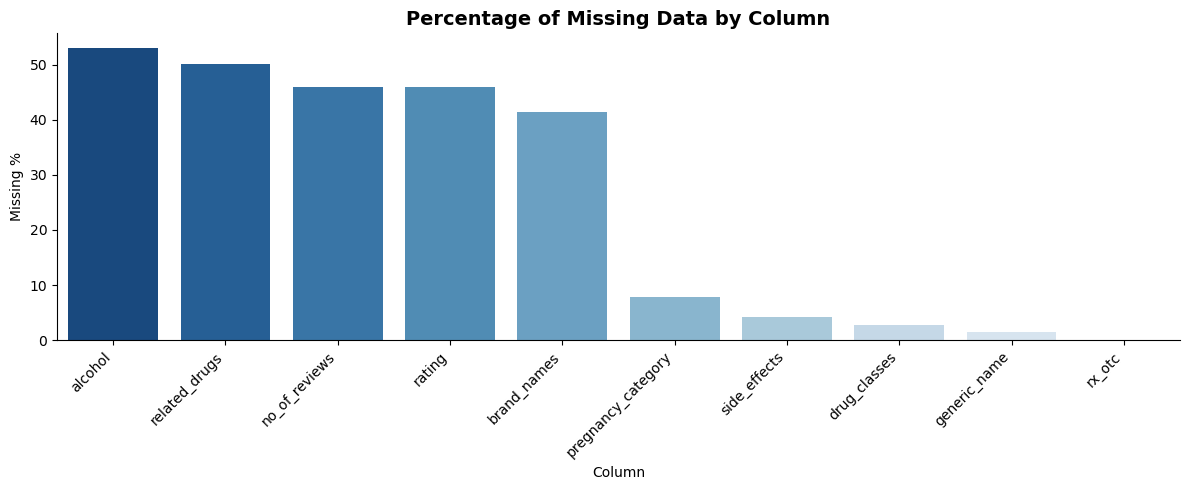

In [8]:
# Visualising Missing Data 

missing_plot = missing[missing["Missing %"] > 0]
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_plot.index, y=missing_plot["Missing %"], palette="Blues_r")
plt.title("Percentage of Missing Data by Column", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "missing_data.png", dpi=150)
plt.show()

### 3.1 Missing Data Observations
- `alcohol` (53%) is **MNAR**: missing values here indicate no known alcohol interaction, not lost data. I Will be engineering into a binary column
- `related_drugs` (50%) is **MNAR**: unique drugs genuinely have no related drugs. I Will be filling with "No Related Drugs"
- `rating` and `no_of_reviews` (46%) is **MNAR**: these are unreviewed drugs on Drugs.com and likely newer or less commonly prescribed. Rows will be retained for non-rating analysis
- `brand_names` (41%) is **MNAR**: this is most likely some drugs that may only exist as generics with no brand name. Will be filled with "No Brand Name"
- `pregnancy_category` (7.81%) is **MAR**: missingness likely related to drug type or age. I will be filling with "N" (FDA not classified)
- `side_effects`, `drug_classes`, `generic_name` have low missingness (<5%) and will be filled with "Not Specified"
- Key observation: `side_effects`, `drug_classes` and `brand_names` store multiple values as delimited strings and will require special parsing during analysis

---
## Data Cleaning
Dropping irrelevant columns, handling missing values, engineering new features and cleaning data types.

### Dropping Irrelevant Columns

In [9]:
# Dropping Irrelevant Columns 
df_clean = df_raw.copy()

cols_to_drop = ["drug_link", "medical_condition_url", "medical_condition_description"]
df_clean.drop(columns=cols_to_drop, inplace=True)

print(f" Remaining columns  : {df_clean.shape[1]}")
print(f" Shape              : {df_clean.shape}")

 Remaining columns  : 14
 Shape              : (2931, 14)


In [10]:
# Handling Missing Values

# Binary encoding of alcohol interaction
df_clean["alcohol_interaction"] = df_clean["alcohol"].apply(
    lambda x: 1 if x == "X" else 0
)
df_clean.drop(columns=["alcohol"], inplace=True)

# Filling categorical columns
fill_map = {
    "related_drugs"      : "No Related Drugs",
    "brand_names"        : "No Brand Name",
    "pregnancy_category" : "N",
    "side_effects"       : "Not Specified",
    "drug_classes"       : "Not Specified",
    "generic_name"       : "Not Specified",
    "rx_otc"             : "Not Specified",
}

for col, fill_value in fill_map.items():
    before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(fill_value)
    print(f" {col:<25} {before} nulls → filled with '{fill_value}'")

# Handling rating and no_of_reviews separately
df_clean["no_of_reviews"] = df_clean["no_of_reviews"].fillna(0)
print(f" {'no_of_reviews':<25} filled with 0")
# Keep rating NaN which i will exclude them in rating-specific analysis
print(f" {'rating':<25} kept as NaN and excluded in rating analysis")

 related_drugs             1469 nulls → filled with 'No Related Drugs'
 brand_names               1213 nulls → filled with 'No Brand Name'
 pregnancy_category        229 nulls → filled with 'N'
 side_effects              124 nulls → filled with 'Not Specified'
 drug_classes              82 nulls → filled with 'Not Specified'
 generic_name              43 nulls → filled with 'Not Specified'
 rx_otc                    1 nulls → filled with 'Not Specified'
 no_of_reviews             filled with 0
 rating                    kept as NaN and excluded in rating analysis


In [11]:
# Cleaning Data Types 

# Activity is stored as "87%",  converting to float
df_clean["activity"] = df_clean["activity"].str.replace("%", "").astype(float)

# Converting no_of_reviews to integer
df_clean["no_of_reviews"] = df_clean["no_of_reviews"].astype(int)

print(f"\nData types after cleaning:")
print(df_clean.dtypes)


Data types after cleaning:
drug_name               object
medical_condition       object
side_effects            object
generic_name            object
drug_classes            object
brand_names             object
activity               float64
rx_otc                  object
pregnancy_category      object
csa                     object
related_drugs           object
rating                 float64
no_of_reviews            int64
alcohol_interaction      int64
dtype: object


In [12]:
# Saving Cleaned Data
df_clean.to_sql("drugs_clean", conn, if_exists="replace", index=False)
df_clean.to_csv(OUTPUTS / "drugs_side_effects_cleaned.csv", index=False)


print(f"Final shape : {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

Final shape : 2,931 rows, 14 columns


### Cleaning Observations
- Dropped 3 irrelevant columns: URLs and condition description as they are web scraping artifacts
- `alcohol` engineered into binary `alcohol_interaction` (1 = interacts, 0 = no interaction) which is more analytically useful than the raw "X" flag
- Categorical missing values filled with meaningful indicators rather than arbitrary values
- `rating` kept as NaN intentionally and will be excluded in rating-specific analysis to avoid distorting results with imputed values
- `activity` successfully converted from percentage string to float for numerical analysis
- Final dataset: 2,931 rows, 14 columns and ready for analysis

---
## **Exploratory Data Analysis**

### **Top Medical Conditions**
Which medical conditions have the most drugs available?

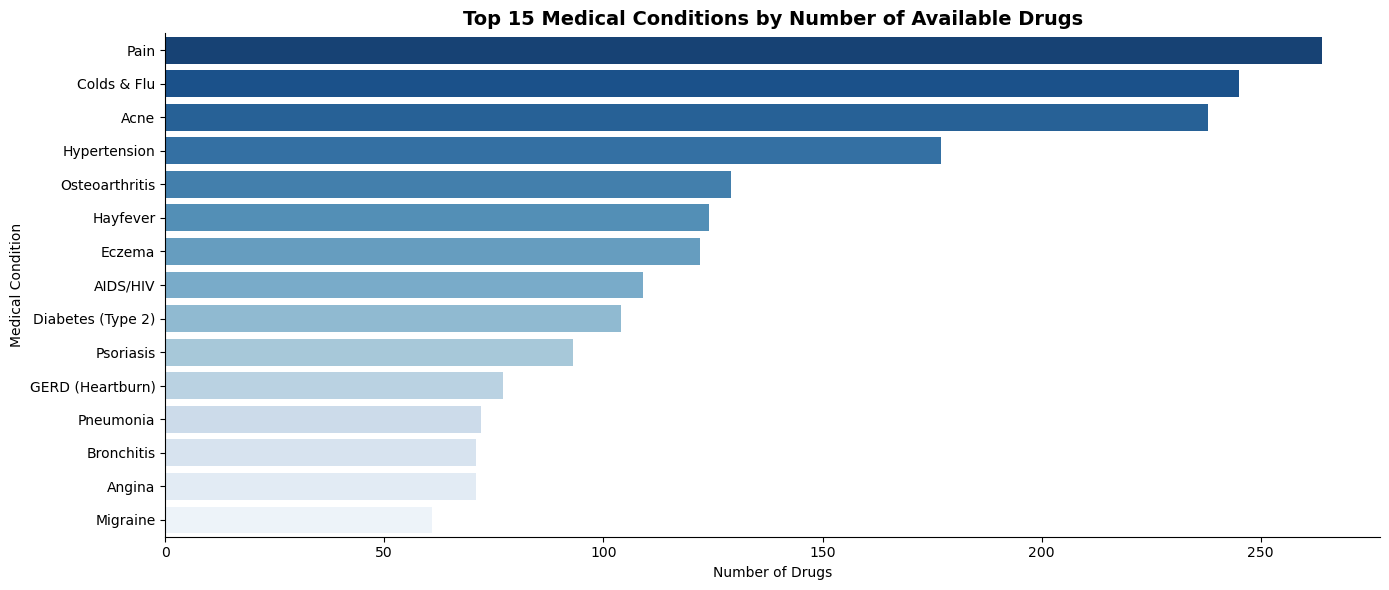

In [13]:
# Top Medical Conditions 
conditions_df = pd.read_sql("""
    SELECT medical_condition, COUNT(*) as Drug_Count
    FROM drugs_clean
    GROUP BY medical_condition
    ORDER BY Drug_Count DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=conditions_df, x="Drug_Count", y="medical_condition", 
            palette="Blues_r")
plt.title("Top 15 Medical Conditions by Number of Available Drugs",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Drugs")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig(OUTPUTS / "top_conditions.png", dpi=150)
plt.show()

### Observations
- Pain, Cold & Flu, and Acne top the list of conditions with the most available drugs
- This reflects market dynamics as highly prevalent conditions that affect large populations drive more drug development and more OTC competition
- These conditions are largely self-managed, meaning pharmaceutical companies have strong commercial incentive to develop multiple competing products
- Serious conditions like Pneumonia and Angina appear lower on the list despite their severity, reflecting the higher complexity and cost of developing drugs for those conditions

### **Prescription vs Over-the-Counter Distribution**
How are drugs distributed across prescription requirements?

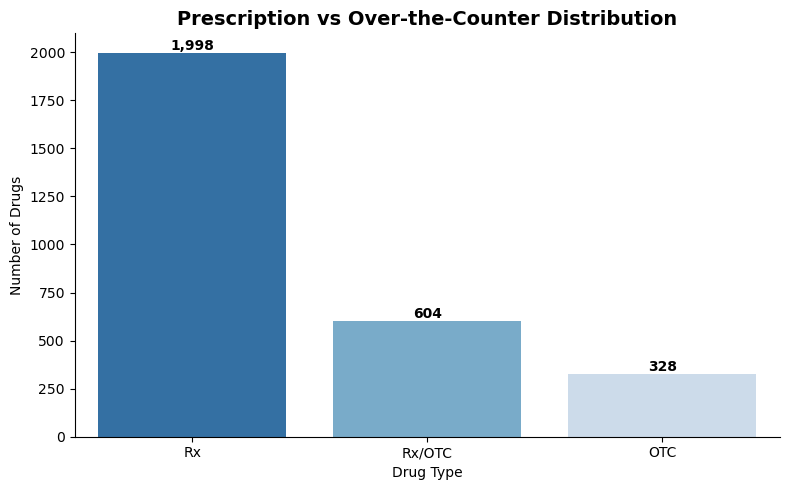

In [14]:
# Rx vs OTC Distribution 
rx_df = pd.read_sql("""
    SELECT rx_otc, COUNT(*) as Count
    FROM drugs_clean
    WHERE rx_otc != 'Not Specified'
    GROUP BY rx_otc
    ORDER BY Count DESC
""", conn)

plt.figure(figsize=(8, 5))
sns.barplot(data=rx_df, x="rx_otc", y="Count", palette="Blues_r")
plt.title("Prescription vs Over-the-Counter Distribution",
          fontsize=14, fontweight="bold")
plt.xlabel("Drug Type")
plt.ylabel("Number of Drugs")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height()):,}",
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "rx_otc.png", dpi=150)
plt.show()

### Observations
- Prescription (Rx) drugs dominate at 1,998 (68%) reflecting heavy regulatory control in the pharmaceutical industry
- Only 328 drugs (11%) are pure OTC, confirming that most medications require professional oversight for safe use.
- 604 drugs (21%) are Rx/OTC meaning they exist in both forms depending on dosage, reflecting the Rx-to-OTC switch process where proven safe drugs are gradually made more accessible
- The dominance of Rx drugs highlights the importance of combating self-medication. Drugs used without proper diagnosis risk masking serious conditions, incorrect dosing, and dangerous drug interactions

### **Pregnancy Safety Category Distribution**
How safe are the available drugs for use during pregnancy?

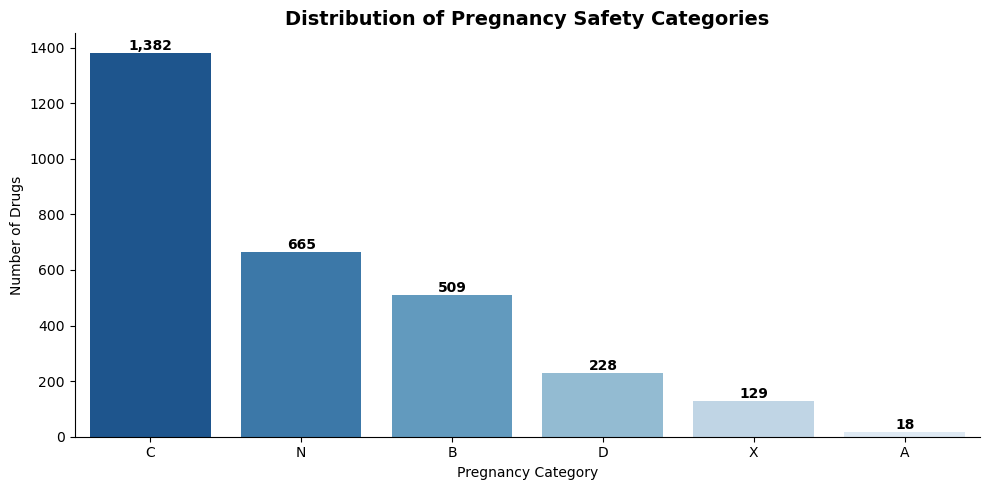

In [15]:
# ── Pregnancy Category Distribution ───────────────────────────────────
preg_df = pd.read_sql("""
    SELECT pregnancy_category, COUNT(*) as Count
    FROM drugs_clean
    GROUP BY pregnancy_category
    ORDER BY Count DESC
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=preg_df, x="pregnancy_category", y="Count", palette="Blues_r")
plt.title("Distribution of Pregnancy Safety Categories",
          fontsize=14, fontweight="bold")
plt.xlabel("Pregnancy Category")
plt.ylabel("Number of Drugs")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height()):,}",
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "pregnancy_categories.png", dpi=150)
plt.show()

### Observations
- Category C dominates at 1,382 drugs (47%) meaning the majority of available drugs have shown adverse fetal effects in animal studies, requiring careful risk-benefit assessment before use in pregnancy
- Only 18 drugs (0.6%) fall under Category which means truly safe medications for pregnant women are extremely rare, highlighting the vulnerability of this population
- 129 drugs are Category X and are absolutely contraindicated in pregnancy, including well-known drugs like Accutane (isotretinoin)
- 665 drugs are Category N FDA unclassified, meaning pregnant patients face additional uncertainty with these medications
- Key clinical implication: pregnant patients must seek professional consultation before taking virtually any medication as self-medication during pregnancy carries serious fetal risk

### **Controlled Substances Act (CSA) Schedule Distribution**
How are drugs distributed across controlled substance schedules?

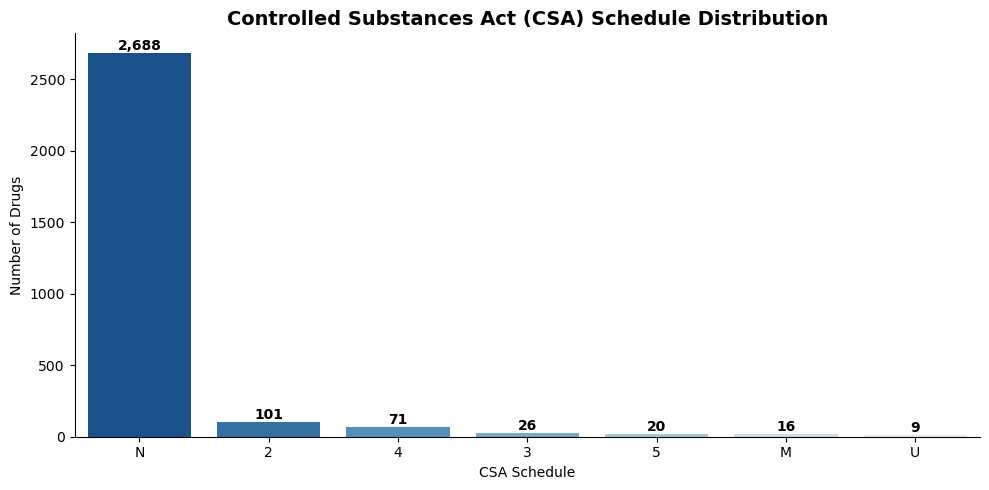

In [16]:
# ──CSA Schedule Distribution ────────────────────────────────────────
csa_df = pd.read_sql("""
    SELECT csa, COUNT(*) as Count
    FROM drugs_clean
    GROUP BY csa
    ORDER BY Count DESC
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=csa_df, x="csa", y="Count", palette="Blues_r")
plt.title("Controlled Substances Act (CSA) Schedule Distribution",
          fontsize=14, fontweight="bold")
plt.xlabel("CSA Schedule")
plt.ylabel("Number of Drugs")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height()):,}",
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "csa_schedule.png", dpi=150)
plt.show()

### Observations
- The vast majority of drugs (2,688 — 92%) fall under "N" and not subject to the Controlled Substances Act, confirming most medications in this dataset are standard non-controlled drugs
- Schedule 2 leads among controlled substances (101 drugs). These include opioids (oxycodone, morphine, fentanyl) and stimulants (Adderall), reflecting high medical utility but also high abuse potential
- Schedule 1 drugs are absent entirely as expected, since Schedule 1 substances have no accepted medical use and would not appear in a clinical drug database
- The small number of Schedule 4 (71) and Schedule 3 (26) drugs reflects the relatively limited set of medications with moderate abuse potential in clinical use
- The presence of controlled substances in this dataset underscores the importance of prescription regulation as these are drugs where misuse carries serious public health consequences

### **Drug Activity & User Ratings Analysis**
Exploring the distribution of drug activity scores and user effectiveness ratings.

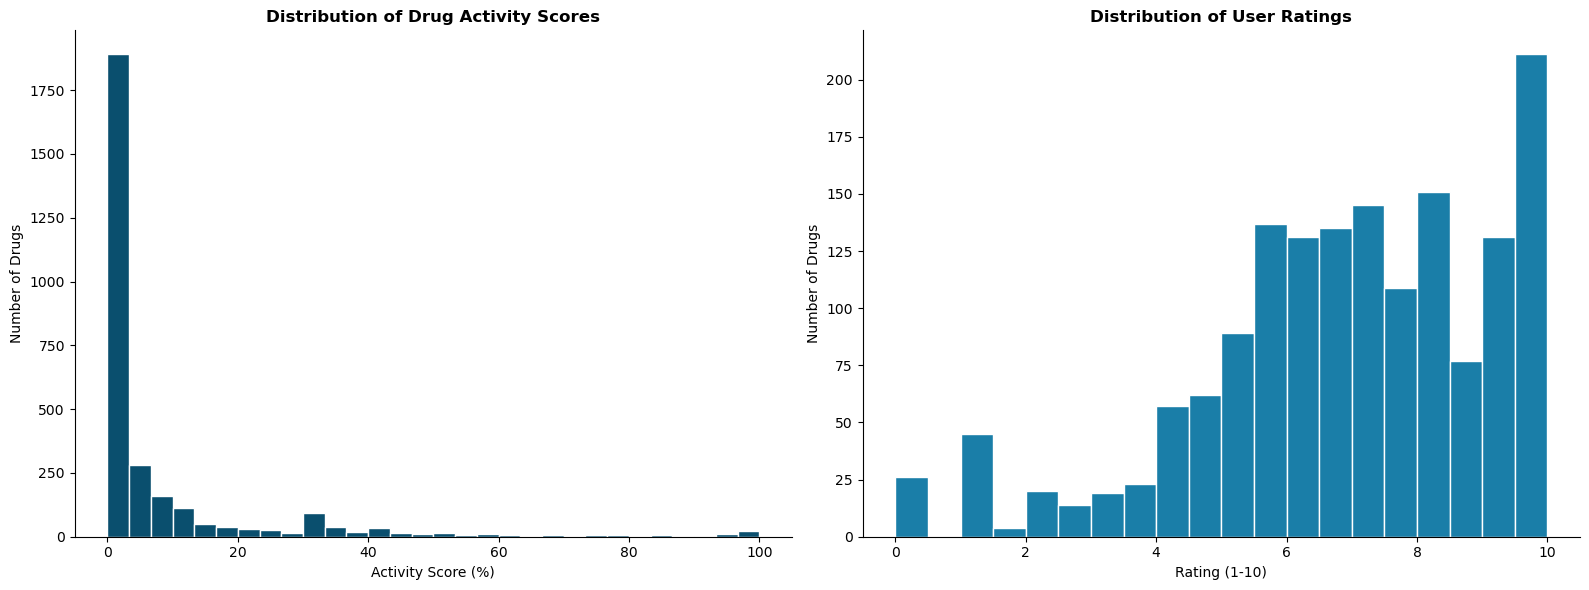

Activity — Mean: 8.5%  Median: 2.0%
Rating   — Mean: 6.81  Median: 7.00


In [17]:
# ──Activity & Rating Distributions ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Activity distribution
axes[0].hist(df_clean["activity"], bins=30, color="#0a4f6e", edgecolor="white")
axes[0].set_title("Distribution of Drug Activity Scores", fontweight="bold")
axes[0].set_xlabel("Activity Score (%)")
axes[0].set_ylabel("Number of Drugs")

# Rating distribution
rating_data = df_clean["rating"].dropna()
axes[1].hist(rating_data, bins=20, color="#1a7ea8", edgecolor="white")
axes[1].set_title("Distribution of User Ratings", fontweight="bold")
axes[1].set_xlabel("Rating (1-10)")
axes[1].set_ylabel("Number of Drugs")

plt.tight_layout()
plt.savefig(OUTPUTS / "activity_rating_dist.png", dpi=150)
plt.show()

print(f"Activity — Mean: {df_clean['activity'].mean():.1f}%  "
      f"Median: {df_clean['activity'].median():.1f}%")
print(f"Rating   — Mean: {rating_data.mean():.2f}  "
      f"Median: {rating_data.median():.2f}")

### Observations
- Activity scores are heavily right skewed. The mean (8.5%) is far above median (2%), indicating most drugs have very low site activity while a small number of highly popular drugs drive the average up
- User ratings skew positively towards 10, with a mean of 6.81 and median of 7.00 suggesting users generally find their medications effective
- However, the rating distribution reflects **survivorship bias** as users who had neutral experiences rarely review, meaning ratings overrepresent strong opinions (very satisfied or very dissatisfied patients)
- The spike at rating 10 is particularly notable as patients who find a drug life-changing are highly motivated to share that experience
- Only 1,586 of 2,931 drugs have ratings. Therefore, analysis of ratings should be interpreted with caution given this significant subset

### **Top Rated Drugs per Medical Condition**
Which drugs have the highest user ratings and for which conditions?

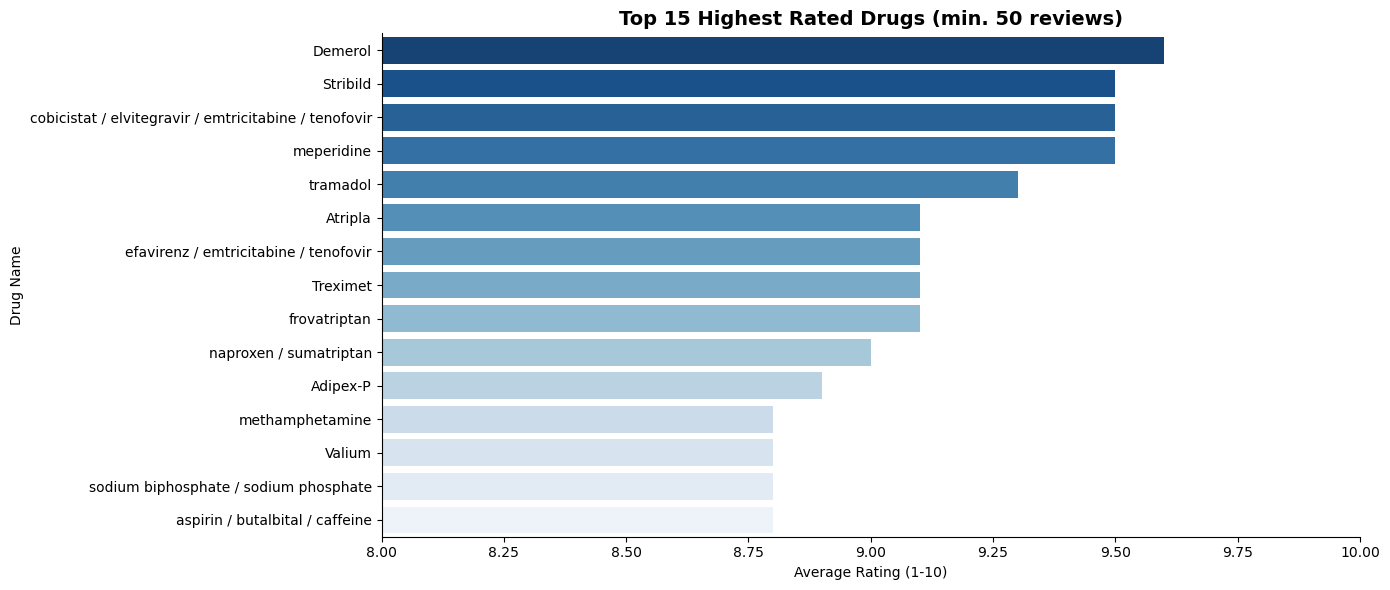

In [18]:
# ──Top Rated Drugs ───────────────────────────────────────────────────
top_rated = pd.read_sql("""
    SELECT drug_name, medical_condition, rating, no_of_reviews
    FROM drugs_clean
    WHERE rating IS NOT NULL
    AND no_of_reviews >= 50
    ORDER BY rating DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_rated, x="rating", y="drug_name", 
            palette="Blues_r", orient="h")
plt.title("Top 15 Highest Rated Drugs (min. 50 reviews)",
          fontsize=14, fontweight="bold")
plt.xlabel("Average Rating (1-10)")
plt.ylabel("Drug Name")
plt.xlim(8, 10)
plt.tight_layout()
plt.savefig(OUTPUTS / "top_rated_drugs.png", dpi=150)
plt.show()

### Observations
- Demerol (meperidine) and tramadol which are both opioid pain medications top the ratings chart, reflecting their high clinical effectiveness but also their psychological satisfaction effect which contributes to dependency and addiction risk
- The presence of highly rated controlled substances (Valium, tramadol) in this list is a public health concern as high patient satisfaction ratings do not account for abuse potential and long-term dependency
- HIV antiretroviral combinations (Stribild, cobicistat/elvitegravir) rate highly, reflecting genuine life-improving impact for patients managing a chronic condition
- The minimum of 50 reviews filter ensures statistical reliability ratings based on small samples would be misleading
- This analysis illustrates why patient satisfaction alone cannot drive drug policy. Effectiveness must be balanced against safety, dependency risk and long term outcomes

### **Alcohol Interaction Analysis**
What proportion of drugs have known alcohol interactions and how does this vary by condition?

   Interacts  No_Interaction  Pct_Interacts
0       1377            1554          46.98


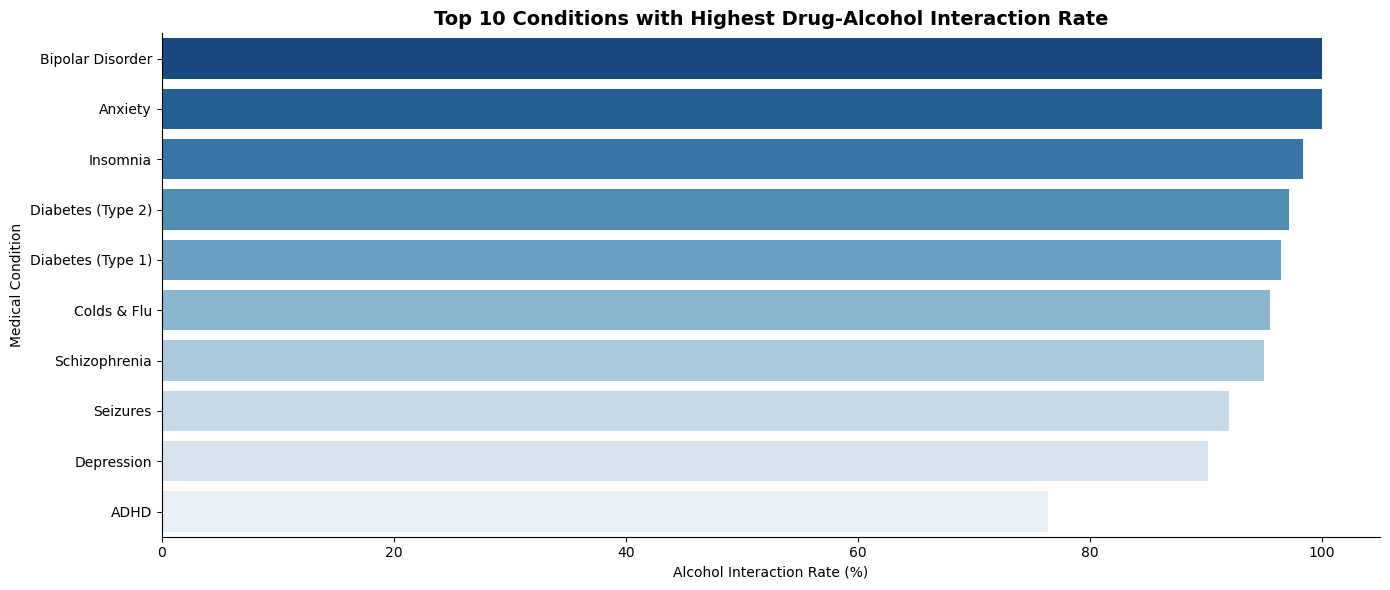

In [19]:
# ──Alcohol Interaction ───────────────────────────────────────────────
alcohol_df = pd.read_sql("""
    SELECT 
        SUM(alcohol_interaction) as Interacts,
        COUNT(*) - SUM(alcohol_interaction) as No_Interaction,
        ROUND(SUM(alcohol_interaction) * 100.0 / COUNT(*), 2) as Pct_Interacts
    FROM drugs_clean
""", conn)

print(alcohol_df)

# top 10 conditions with highest alcohol interaction rate
alcohol_condition = pd.read_sql("""
    SELECT medical_condition,
           COUNT(*) as Total,
           SUM(alcohol_interaction) as Interacts,
           ROUND(SUM(alcohol_interaction) * 100.0 / COUNT(*), 2) as Interaction_Rate
    FROM drugs_clean
    GROUP BY medical_condition
    HAVING Total >= 10
    ORDER BY Interaction_Rate DESC
    LIMIT 10
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=alcohol_condition, x="Interaction_Rate", 
            y="medical_condition", palette="Blues_r")
plt.title("Top 10 Conditions with Highest Drug-Alcohol Interaction Rate",
          fontsize=14, fontweight="bold")
plt.xlabel("Alcohol Interaction Rate (%)")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig(OUTPUTS / "alcohol_interaction.png", dpi=150)
plt.show()

### Observations
- 47% of all drugs (1,377) have known alcohol interactions. This is a significant public health finding given how commonly alcohol is consumed alongside medications
- Bipolar Disorder and Anxiety show 100% alcohol interaction rates. Every single drug for these conditions interacts with alcohol
- Psychiatric and neurological conditions dominate the top 10 because their medications act on the Central Nervous System (CNS) which is the same pathway alcohol affects. Combining these drugs with alcohol amplifies sedation, impairs cognitive function and can be fatal
- Both types of Diabetes appear due to alcohol's direct interference with blood sugar regulation, compounding the risk for diabetic patients
- This analysis has direct clinical implications as healthcare providers must consistently counsel patients on alcohol avoidance when prescribing CNS-acting medications

### **Most Common Drug Classes**
Parsing multi-value drug class strings to identify the most represented drug classes.

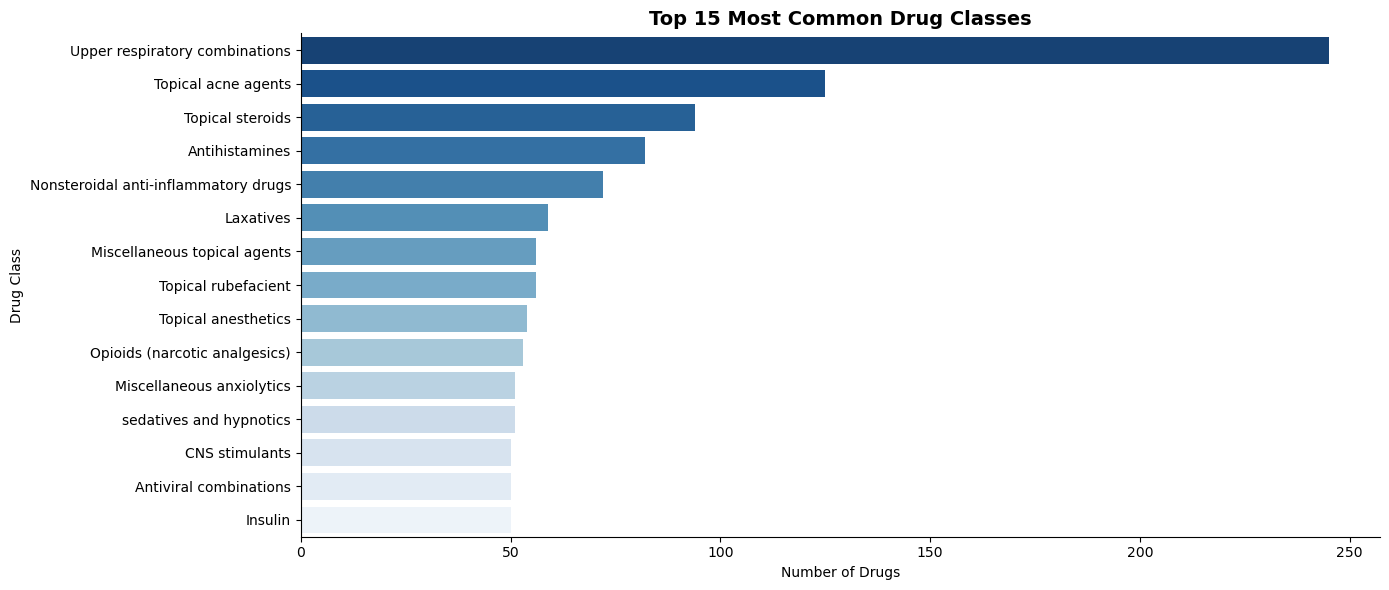

In [20]:
# ──Drug Classes Analysis ────────────────────────────────────────────
# Split delimited drug classes and count individual occurrences
all_classes = []
for entry in df_clean["drug_classes"]:
    if entry != "Not Specified":
        classes = [c.strip() for c in entry.split(",")]
        all_classes.extend(classes)

class_counts = pd.DataFrame(
    Counter(all_classes).most_common(15),
    columns=["Drug_Class", "Count"]
)

plt.figure(figsize=(14, 6))
sns.barplot(data=class_counts, x="Count", y="Drug_Class", palette="Blues_r")
plt.title("Top 15 Most Common Drug Classes",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Drugs")
plt.ylabel("Drug Class")
plt.tight_layout()
plt.savefig(OUTPUTS / "drug_classes.png", dpi=150)
plt.show()

### Observations
- Upper Respiratory Combinations dominate at ~245 drugs which is directly consistent with Cold & Flu being one of the top conditions by drug count. These are multi-ingredient products combining decongestants, antihistamines and analgesics
- Topical Acne Agents (130) and Topical Steroids (95) reflect the high volume of skin condition treatments in this dataset
- Antihistamines and NSAIDs (Non-Steroidal Anti-Inflammatory Drugs) feature prominently. Both are widely used across multiple conditions including allergies, pain and inflammation
- Opioids (narcotic analgesics) appearing in the top 15 is consistent with Pain being the top condition and opioids dominating user ratings. Confirming their widespread clinical use despite high abuse potential
- The presence of Sedatives, Anxiolytics and CNS Stimulants reflects the significant burden of psychiatric conditions in this dataset

---
## **Summary Statistics & Conclusions**

In [21]:
# ──Summary Statistics ───────────────────────────────────────────────
summary = pd.read_sql("""
    SELECT
        COUNT(*) as Total_Drugs,
        COUNT(DISTINCT medical_condition) as Unique_Conditions,
        ROUND(AVG(rating), 2) as Avg_Rating,
        ROUND(AVG(activity), 2) as Avg_Activity_Score,
        SUM(CASE WHEN rx_otc = 'Rx' THEN 1 ELSE 0 END) as Prescription_Only,
        SUM(CASE WHEN rx_otc = 'OTC' THEN 1 ELSE 0 END) as OTC_Only,
        SUM(CASE WHEN pregnancy_category = 'X' THEN 1 ELSE 0 END) as Contraindicated_Pregnancy,
        SUM(CASE WHEN pregnancy_category = 'A' THEN 1 ELSE 0 END) as Safe_Pregnancy,
        SUM(alcohol_interaction) as Alcohol_Interactions,
        SUM(CASE WHEN csa NOT IN ('N', 'U') THEN 1 ELSE 0 END) as Controlled_Substances
    FROM drugs_clean
""", conn)

summary.T.rename(columns={0: "Value"})

,Value
Total_Drugs,2931.00
Unique_Conditions,47.00
Avg_Rating,6.81
Avg_Activity_Score,8.45
Prescription_Only,1998.00
OTC_Only,328.00
Contraindicated_Pregnancy,129.00
Safe_Pregnancy,18.00
Alcohol_Interactions,1377.00
Controlled_Substances,234.00


## **Conclusions**

### **Key Metrics**

| Metric | Value |
|--------|-------|
| Total Drugs | 2,931 |
| Unique Medical Conditions | 47 |
| Average User Rating | 6.81 / 10 |
| Average Activity Score | 8.45% |
| Prescription Only | 1,998 (68%) |
| OTC Only | 328 (11%) |
| Contraindicated in Pregnancy | 129 |
| Safe in Pregnancy (Category A) | 18 |
| Alcohol Interactions | 1,377 (47%) |
| Controlled Substances | 234 |

### **Summary of Findings**

1. **Market Concentration:** Pain, Cold & Flu and Acne have the highest number of available drugs. High prevalence conditions drive pharmaceutical market competition

2. **Heavy Regulation:** 68% of drugs are prescription-only, confirming that most medications require professional oversight. Self-medication poses serious risks including misdiagnosis, incorrect dosing and dangerous interactions

3. **Pregnancy Risk:** Only 18 drugs are classified as completely safe in pregnancy (Category A) while 129 are absolutely contraindicated (Category X). Pregnant patients face significant medication risk and must always seek professional guidance

4. **Alcohol Interactions:** 47% of drugs interact with alcohol. Psychiatric and neurological medications show the highest interaction rates due to shared CNS pathways. This has direct implications for patient counselling

5. **Opioid Paradox:** Opioids rank among the highest rated drugs reflecting genuine pain relief effectiveness, but their high satisfaction ratings also reflect psychological dependency mechanisms — a critical public health concern

6. **Drug Classes:** Upper respiratory combinations dominate drug classes, consistent with Cold & Flu being a top condition. CNS-acting drug classes (anxiolytics, sedatives, stimulants) reflect significant psychiatric disease burden

### **Limitations**
- Rating data covers only 54% of drugs — findings may not represent the full dataset
- Activity scores reflect Drugs.com site traffic, not clinical effectiveness
- Alcohol interaction data is binary. Severity of interactions varies significantly and is not captured here
- Dataset represents a snapshot and may not reflect current drug approvals or withdrawals

In [22]:
# ── Close Connection ──────────────────────────────────────────────────
conn.close()